# Lotka-Volterra predator-prey model: backward Euler with Newton subiterations

Companion notebook for Section 4.2.1 of `Lec4.tex`. Solves the Lotka-Volterra system
$$
\frac{du_1}{dt} = \alpha u_1 - \beta u_1 u_2, \qquad
\frac{du_2}{dt} = \delta u_1 u_2 - \gamma u_2,
$$
using only the backward Euler method (Algorithm 4.3), with the Newton
subiterations driven by the exact Jacobian derived in the notes,
$$
D_{\mathbf{u}} \mathbf{f}(t,\mathbf{u}) = \begin{bmatrix}
    \alpha - \beta u_2 & -\beta u_1 \\
    \delta u_2 & \delta u_1 - \gamma
\end{bmatrix}.
$$
Here $u_1$ is the prey population and $u_2$ is the predator population.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# model parameters (free to tune)
alpha = 1.0
beta = 0.1
gamma = 1.5
delta = 0.075

# initial condition, time interval, and step size
u0 = np.array([10.0, 5.0])  # (prey, predator)
T = 30.0
delta_t = 0.05

# Newton solver settings
tol = 1e-10
max_newton_iter = 50

N = int(round(T / delta_t))

In [3]:
def f(t, u, alpha, beta, gamma, delta):
    u1, u2 = u
    return np.array([
        alpha * u1 - beta * u1 * u2,
        delta * u1 * u2 - gamma * u2,
    ])


def Df(t, u, alpha, beta, gamma, delta):
    u1, u2 = u
    return np.array([
        [alpha - beta * u2, -beta * u1],
        [delta * u2, delta * u1 - gamma],
    ])

In [4]:
def backward_euler_newton_system(u0, f, Df, delta_t, N, tol=1e-10, max_iter=50,
                                  **params):
    """Algorithm 4.3: backward Euler with Newton subiterations for systems.

    At each step solves g(v) = v - u_n - delta_t*f(t_{n+1}, v) = 0 via
        v_{k+1} = v_k - (I - delta_t*Df(t_{n+1}, v_k))^{-1} g(v_k),
    implemented with a linear solve rather than an explicit matrix inverse.
    """
    d = u0.size
    t = delta_t * np.arange(N + 1)
    u = np.empty((N + 1, d))
    u[0] = u0
    newton_iters = np.empty(N, dtype=int)

    I = np.eye(d)
    for n in range(N):
        v = u[n].copy()
        t_next = t[n + 1]
        for k in range(max_iter):
            g = v - u[n] - delta_t * f(t_next, v, **params)
            Jg = I - delta_t * Df(t_next, v, **params)
            step = np.linalg.solve(Jg, g)
            v_new = v - step
            if np.linalg.norm(v_new - v) < tol:
                v = v_new
                break
            v = v_new
        newton_iters[n] = k + 1
        u[n + 1] = v

    return t, u, newton_iters

In [5]:
t, u, newton_iters = backward_euler_newton_system(
    u0, f, Df, delta_t, N, tol=tol, max_iter=max_newton_iter,
    alpha=alpha, beta=beta, gamma=gamma, delta=delta,
)

print(f"alpha={alpha}, beta={beta}, gamma={gamma}, delta={delta}")
print(f"delta_t={delta_t}, N={N} steps")
print(f"average Newton subiterations per step: {newton_iters.mean():.2f} "
      f"(max {newton_iters.max()})")

alpha=1.0, beta=0.1, gamma=1.5, delta=0.075
delta_t=0.05, N=600 steps
average Newton subiterations per step: 3.64 (max 4)


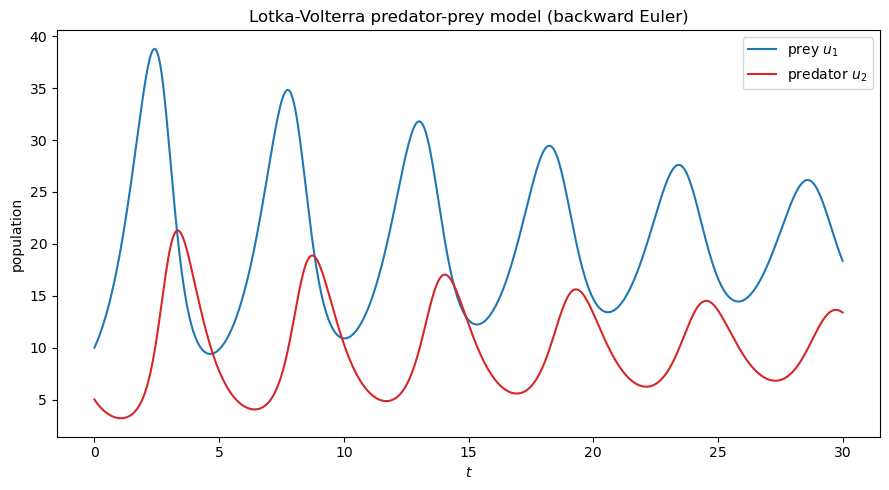

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t, u[:, 0], color="tab:blue", label="prey $u_1$")
ax.plot(t, u[:, 1], color="tab:red", label="predator $u_2$")
ax.set_xlabel("$t$")
ax.set_ylabel("population")
ax.set_title("Lotka-Volterra predator-prey model (backward Euler)")
ax.legend()

fig.tight_layout()
fig.savefig("lotka_volterra.png", dpi=300, bbox_inches="tight")
plt.show()